In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
carrier_display_names = {
    "onwind": "Onshore wind",
    "offwind-ac": "Offshore wind (AC)",
    "offwind-float": "Offshore wind (floating)",
    "solar": "Solar PV",
    "solar-hsat": "Solar PV (high satellite)",
    "hydro": "Hydro",
    "ror": "Run-of-river",
    "lignite": "Lignite",
    "coal": "Coal",
    "oil": "Oil",
    "OCGT": "OCGT",
    "CCGT": "CCGT",
    "gas": "Gas",
    "biomass": "Biomass",
    "waste": "Waste",
    "geothermal": "Geothermal",
    "load": "Unserved Load",
    "battery discharge": "Battery discharge",
}

def carrier_label(name):
    return carrier_display_names.get(name, name)

In [4]:
# Load and combine generation + consumption data for each scenario
actual_electricity_data = {}

# Define rename map for generation carriers
rename_map = {
    'Biomass': 'biomass', 'Hydropower': 'hydro', 'Wind offshore': 'offwind-ac',
    'Wind onshore': 'onwind', 'Photovoltaics': 'solar', 'Other renewable': 'waste',
    'Nuclear': 'nuclear', 'Lignite': 'lignite', 'Hard coal': 'coal',
    'Fossil gas': 'gas', 'Hydro pumped storage': 'hydro', 'Other conventional': 'oil'
}
scenario_titles = {
    "Windy": "Windy Day (2025-10-26)",
    "Not Windy": "Not Windy Day (2025-04-08)",
    "Wind Variability": "Wind Variability Day (2025-10-06)"
}

real_data_paths = {
    "Windy": {
        "generation": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_generation_202510260000_202510270000_Hour.csv",
        "consumption": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_consumption_202510260000_202510270000_Hour_2.csv"
    },
    "Not Windy": {
        "generation": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_generation_202504080000_202504090000_Hour.csv",
        "consumption": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_consumption_202504080000_202504090000_Hour_2.csv"
    },
    "Wind Variability": {
        "generation": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_generation_202510060000_202510070000_Hour.csv",
        "consumption": "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Actual_consumption_202510060000_202510070000_Hour_2.csv"
    }
}

for scenario_title, paths in real_data_paths.items():
    # --- Load Generation Data ---
    gen_df = pd.read_csv(paths["generation"], sep=';', thousands=',', na_values=['-'])
    # Use End date minus one hour as the timestamp to avoid ambiguous '12:00 AM' entries
    gen_df['timestamp'] = pd.to_datetime(gen_df['End date'], format='mixed', errors='coerce') - pd.Timedelta(hours=1)
    gen_df = gen_df.set_index('timestamp')
    # Drop original date columns
    gen_df = gen_df.drop(['Start date', 'End date'], axis=1, errors='ignore')
    
    # Clean column names
    gen_df.columns = [c.replace(' [MWh] Calculated resolutions', '') for c in gen_df.columns]
    
    # Apply rename map to generation carriers
    gen_df = gen_df.rename(columns=rename_map)
    
    # Aggregate duplicate column names (e.g., "hydro" appears twice)
    gen_df = gen_df.T.groupby(level=0).sum().T
    
    # Drop generation columns that are entirely zero
    gen_df = gen_df.loc[:, gen_df.ne(0).any(axis=0)]
    
    # --- Load Consumption Data ---
    cons_df = pd.read_csv(paths["consumption"], sep=';', thousands=',', decimal='.')

    # Prefer End date as timestamp if present, else fall back to first date-like column
    if 'End date' in cons_df.columns:
        cons_df['timestamp'] = pd.to_datetime(cons_df['End date'], format='mixed', errors='coerce') - pd.Timedelta(hours=1)
    else:
        # find a date-like column
        date_col_candidates = [c for c in cons_df.columns if 'date' in c.lower()]
        date_col = date_col_candidates[0] if date_col_candidates else cons_df.columns[0]
        cons_df['timestamp'] = pd.to_datetime(cons_df[date_col], format='mixed', errors='coerce')

    cons_df = cons_df.set_index('timestamp')

    # --- Extract consumption (load) columns safely ---
    load_col_map = {
        'grid load [MWh] Calculated resolutions': 'grid load',
        'Grid load incl. hydro pumped storage [MWh] Calculated resolutions': 'grid load with hydro storage',
    }
    present_load_cols = [c for c in load_col_map.keys() if c in cons_df.columns]
    if present_load_cols:
        consumption_data = cons_df[present_load_cols].rename(columns={k: load_col_map[k] for k in present_load_cols})
        consumption_data = consumption_data.apply(pd.to_numeric, errors='coerce').fillna(0)
        # Drop load columns that are entirely zero
        consumption_data = consumption_data.loc[:, consumption_data.ne(0).any(axis=0)]
    else:
        consumption_data = pd.DataFrame(index=cons_df.index)

    # --- Combine Generation + Consumption Columns ---
    combined_df = pd.concat([gen_df, consumption_data], axis=1)

    # Aggregate duplicate timestamps (if any) and sort index so plotting axes are consistent
    if combined_df.index.duplicated().any():
        combined_df = combined_df.groupby(level=0).mean(numeric_only=True)
    combined_df = combined_df.sort_index()

    # Store in dictionary
    actual_electricity_data[scenario_title] = combined_df

    # export to CSV for later use
    combined_df.to_csv(f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv")

Sum of all demand: 1079121.805
Sum of all demand: 1301074.17
Sum of all demand: 1367487.3399999999


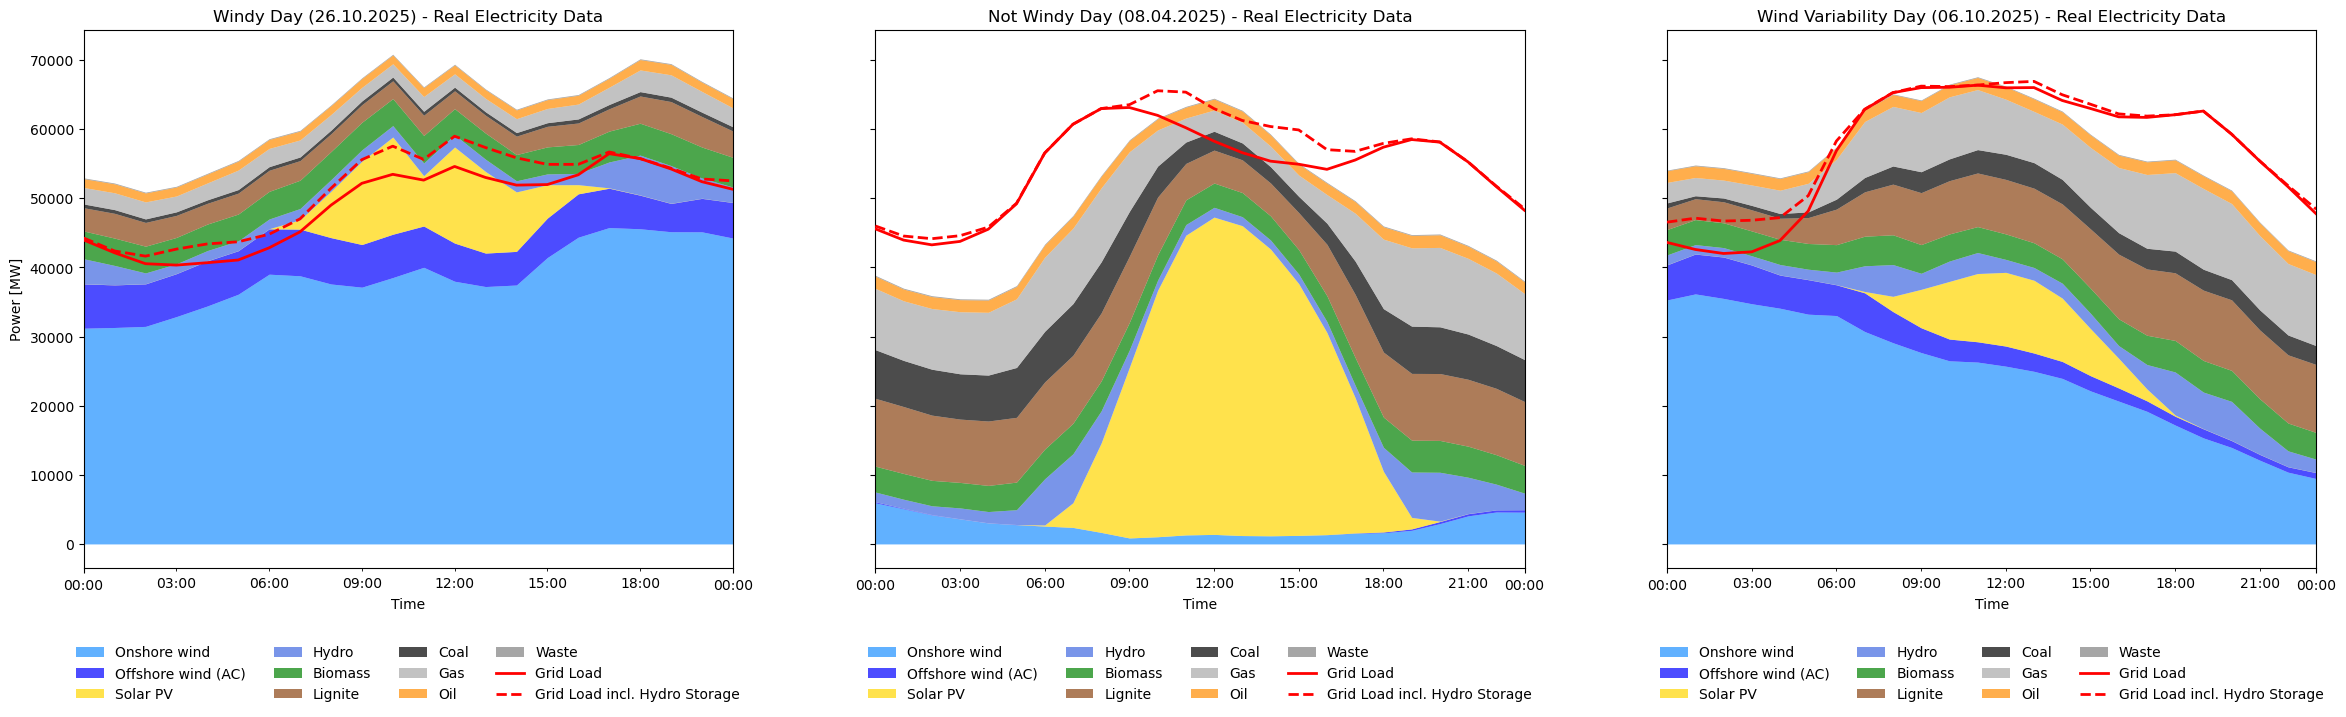

Sum of all demand: 1079121.805
Sum of all demand: 1301074.17
Sum of all demand: 1367487.3399999999


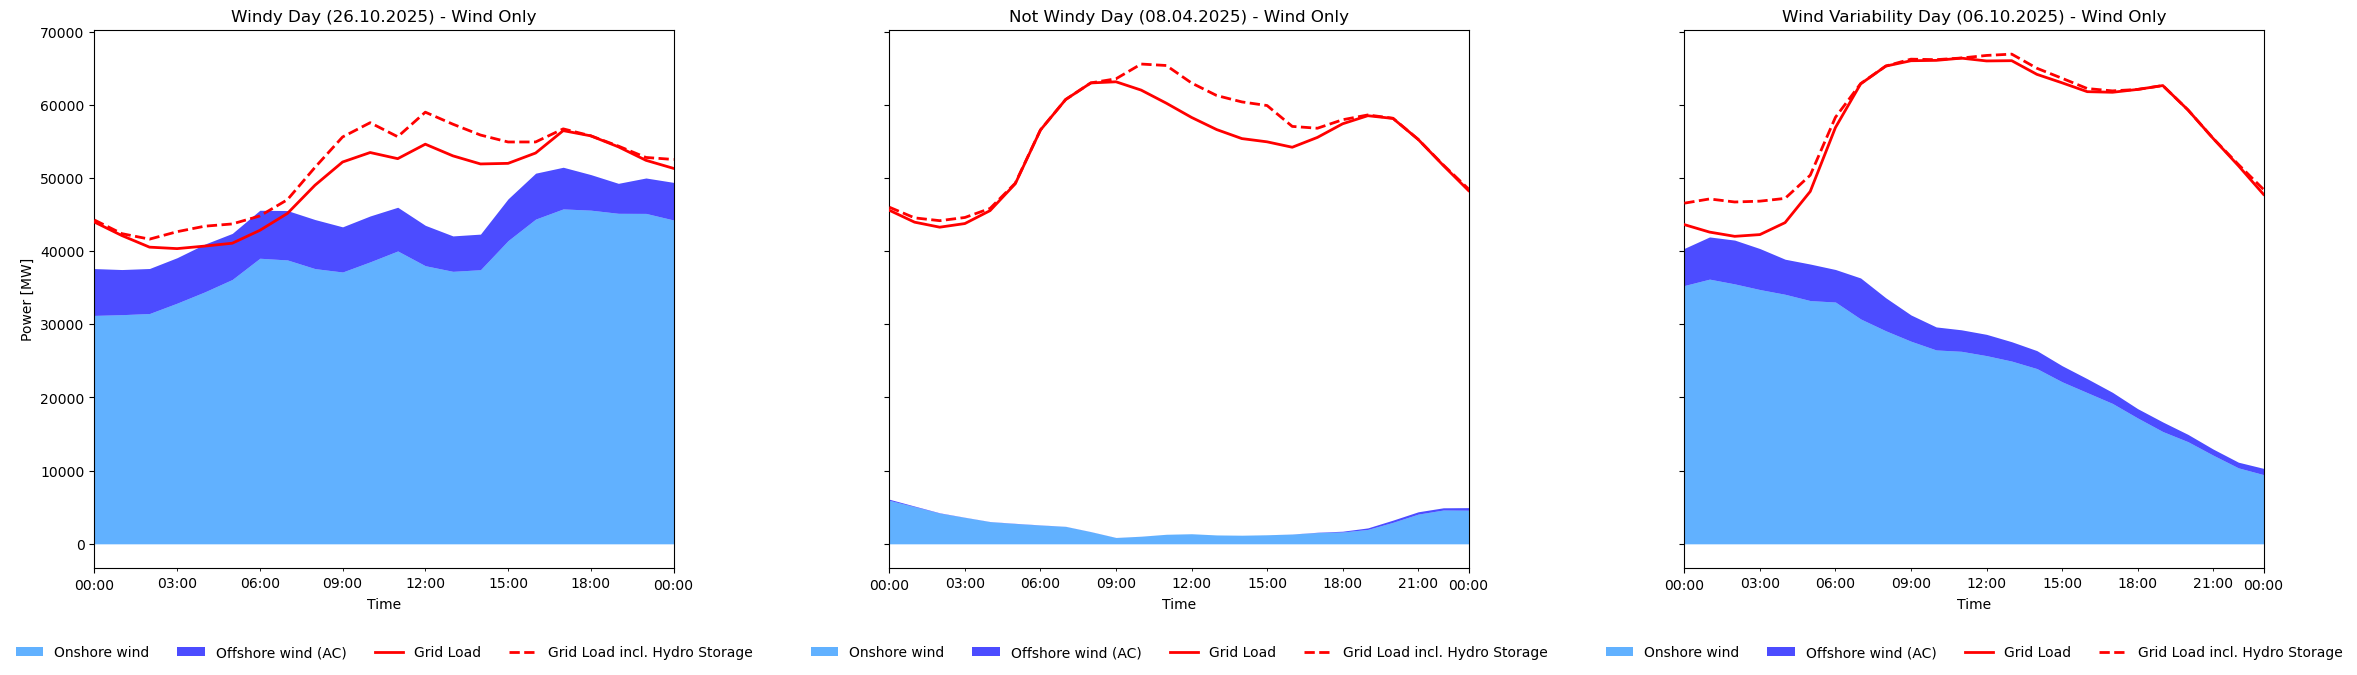

In [5]:
base_carrier_order = [
    "onwind", "offwind-ac",
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass",
    "lignite", "coal", "gas", "oil",
]

carrier_colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "blue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "gas": "darkgray",
    "oil": "darkorange",
    # Other
    "biomass": "green",
    "geothermal": "firebrick",
    "battery discharge": "purple",
}

def plot_real_electricity_data(actual_electricity_data, scenario_titles, carriers_to_plot, title_suffix="", carrier_order=None):
    fig, axes = plt.subplots(1, len(scenario_titles), figsize=(24, 7), sharey=True)

    if len(scenario_titles) == 1:
        axes = [axes]

    grid_lines = ("grid load", "grid load with hydro storage")
    carriers_to_plot = [c for c in carriers_to_plot if c not in grid_lines]
    if carrier_order is None:
        carrier_order = carriers_to_plot

    for ax, scenario_title in zip(axes, scenario_titles):
        df = actual_electricity_data[scenario_title].copy().sort_index()

        if df.index.duplicated().any():
            df = df.groupby(level=0).mean(numeric_only=True)

        plot_area_cols = [c for c in carrier_order if c in carriers_to_plot and c in df.columns]
        plot_area_cols += [c for c in carriers_to_plot if c not in carrier_order and c in df.columns]

        if not plot_area_cols and not any(g in df.columns for g in grid_lines):
            ax.set_visible(False)
            continue

        if plot_area_cols:
            plot_df = df[plot_area_cols].copy()
            plot_colors = [carrier_colors.get(col, "gray") for col in plot_df.columns]
            plot_df.plot(kind="area", ax=ax, lw=0, color=plot_colors, alpha=0.7)

        if "grid load" in df.columns:
            df["grid load"].plot(ax=ax, color="red", lw=2, label="Grid Load", zorder=10)
            print(f"Sum of all demand: {df['grid load'].sum()}")
        if "grid load with hydro storage" in df.columns:
            df["grid load with hydro storage"].plot(
                ax=ax,
                color="red",
                lw=2,
                linestyle="--",
                label="Grid Load incl. Hydro Storage",
                zorder=9,
            )

        handles, labels = ax.get_legend_handles_labels()
        new_labels = [carrier_display_names.get(lbl, lbl) for lbl in labels]

        date = df.index[0].strftime("%d.%m.%Y")
        if title_suffix:
            ax.set_title(f"{scenario_title} Day ({date}) - {title_suffix}")
        else:
            ax.set_title(f"{scenario_title} Day ({date})")
        ax.set_ylabel("Power [MW]")
        ax.set_xlabel("Time")
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
        ax.legend(
            handles,
            new_labels,
            ncol=4,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            frameon=False,
        )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    plt.show()

    save_path = f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/real_electricity_data_comparison_{title_suffix}.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")


# Use the reusable plotting function for the full set of carriers currently shown
all_carriers_to_plot = base_carrier_order.copy()
for scenario_df in actual_electricity_data.values():
    for carrier in scenario_df.columns:
        if carrier not in ("grid load", "grid load with hydro storage") and carrier not in all_carriers_to_plot:
            all_carriers_to_plot.append(carrier)


plot_real_electricity_data(
    actual_electricity_data,
    scenario_titles,
    all_carriers_to_plot,
    title_suffix="Real Electricity Data",
    carrier_order=base_carrier_order,
)


# Use the same function for a wind-only view
wind_carriers_to_plot = ["onwind", "offwind-ac", "offwind-float"]
plot_real_electricity_data(
    actual_electricity_data,
    scenario_titles,
    wind_carriers_to_plot,
    title_suffix="Wind Only",
    carrier_order=base_carrier_order,
)



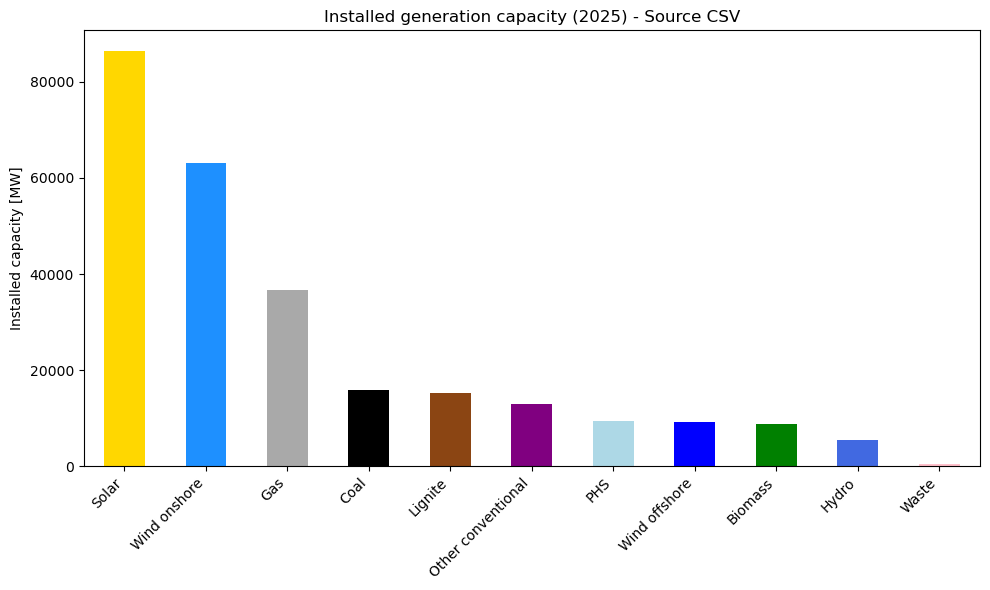

Total installed capacity (CSV): 263475.0
Solar                 86408.0
Wind onshore          63192.0
Gas                   36614.0
Coal                  15951.0
Lignite               15178.0
Other conventional    12971.0
PHS                    9384.0
Wind offshore          9215.0
Biomass                8766.0
Hydro                  5350.0
Waste                   446.0


In [6]:
# Plot installed capacities from CSV
import numpy as np
installed_capacity_path = "/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/Installed_generation_capacity_202305130000_202505130000_Year.csv"

# Read CSV
df_inst = pd.read_csv(installed_capacity_path, sep=';')
if df_inst.empty:
    raise ValueError(f"No data in {installed_capacity_path}")
row = df_inst.iloc[0]

# Map CSV columns to carrier keys
graphic_map = {
    'Biomass [MW] Original resolutions': 'Biomass',
    'Hydropower [MW] Original resolutions': 'Hydro',
    'Wind offshore [MW] Original resolutions': 'Wind offshore',
    'Wind onshore [MW] Original resolutions': 'Wind onshore',
    'Photovoltaics [MW] Original resolutions': 'Solar',
    'Other renewable [MW] Original resolutions': 'Waste',
    'Nuclear [MW] Original resolutions': 'Nuclear',
    'Lignite [MW] Original resolutions': 'Lignite',
    'Hard coal [MW] Original resolutions': 'Coal',
    'Fossil gas [MW] Original resolutions': 'Gas',
    'Hydro pumped storage [MW] Original resolutions': 'PHS',
    'Other conventional [MW] Original resolutions': 'Other conventional',
}

data = {}
for src, dest in graphic_map.items():
    if src in row.index:
        v = row[src]
        if pd.isna(v):
            continue
        # Remove thousands separators and convert
        if isinstance(v, str):
            v = v.replace(',', '')
        try:
            data[dest] = float(v)
        except Exception:
            continue

series = pd.Series(data).sort_values(ascending=False)

# Colors
colors = {
    'Wind onshore': 'dodgerblue', 'Wind offshore': 'blue',
    'Solar': 'gold', 
    'Hydro': 'royalblue', 
    'Lignite': 'saddlebrown', 'Coal': 'black', 'Gas': 'darkgray', 'Oil': 'darkorange',
    'Biomass': 'green', 'Waste': 'pink', 'Geothermal': 'firebrick', 'PHS': 'lightblue', 'Other conventional': 'purple'
}
bar_colors = [colors.get(c, 'gray') for c in series.index]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
series.plot(kind='bar', color=bar_colors, ax=ax)
ax.set_ylabel('Installed capacity [MW]')
ax.set_title('Installed generation capacity (2025) - Source CSV')
ax.set_xticklabels(series.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print('Total installed capacity (CSV):', series.sum())
print(series.to_string())
